# Sistema de Análisis del Mercado de Automoción

### Crisitian Cabrera Pinto y Álex Rafael de la Cruz Sánchez

Trabajo SBD y SAA

In [61]:
#Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [62]:
#Lectura de ficheros
df_vehiculos = pd.read_csv('vehiculos.json')
df_ventas_mantenimiento = pd.read_csv('ventas_mantenimiento.csv')
df_opiniones = pd.read_csv('opiniones_clientes.xml')

In [63]:
df_vehiculos.head()

,vehiculo_id,marca,modelo,anio_fabricacion,combustible,transmision,potencia_cv,cilindrada,consumo_urbano,consumo_extraurbano,emisiones_co2,precio_base,segmento
0,VH001,Peugeot,208,2018,Híbrido,Manual,147,1400,6.9,5.5,149,34600,Compacto
1,VH002,Hyundai,i20,2018,Gasolina,Manual,219,2000,4.1,4.1,149,36500,Sedán
2,VH003,Kia,Ev6,2020,Híbrido,Manual,130,2200,5.7,4.3,107,34800,Deportivo
3,VH004,Ford,Puma,2018,Gasolina,Automática,178,2000,5.1,3.6,138,35200,SUV
4,VH005,Hyundai,i20,2022,Gasolina,Automática,237,1400,6.8,3.6,109,38800,SUV


In [64]:
df_ventas_mantenimiento.head()

,venta_id,vehiculo_id,fecha_venta,region_vendedor,precio_venta_real,kilometraje_venta,servicios_realizados,coste_mantenimiento_anual,incidencias_mecanicas,valor_residual_estimado
0,VT001,VH001,2023-03-01,Cataluña,34536,168,0,992,0,12937
1,VT002,VH001,2023-01-24,País Vasco,31929,9835,1,992,0,6894
2,VT003,VH001,2023-10-11,País Vasco,30964,16270,3,992,0,10366
3,VT004,VH002,2023-10-20,Andalucía,31897,44127,0,1030,0,6739
4,VT005,VH003,2023-08-27,Andalucía,34964,20361,2,896,3,18098


In [65]:
df_opiniones.head()

,review_id,vehiculo_id,cliente_id,puntuacion_conjunta,confort,seguridad,eficiencia,diseno,fiabilidad,recomendacion,texto_review
0,RV001,VH204,CUST173,3.4,3.4,3.9,4.8,3.6,3.0,No,"Problemático, poco espacio"
1,RV002,VH249,CUST034,3.0,3.1,3.4,4.1,2.9,2.6,No,"Decepcionante, poco espacio"
2,RV003,VH244,CUST038,5.0,5.0,5.0,5.0,5.0,5.0,Si,"Eficiente vehículo, gran rendimiento"
3,RV004,VH280,CUST022,3.9,3.9,3.9,4.8,3.5,3.1,Si,"Problemático, precio elevado"
4,RV005,VH125,CUST153,4.0,4.2,4.5,4.2,4.1,5.0,Si,"Lento, precio elevado"


### Fase 0: Datos

¿Que datos tiene el fichero de vehiculos?

In [66]:
df_vehiculos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   vehiculo_id          300 non-null    object 
 1   marca                300 non-null    object 
 2   modelo               300 non-null    object 
 3   anio_fabricacion     300 non-null    int64  
 4   combustible          300 non-null    object 
 5   transmision          300 non-null    object 
 6   potencia_cv          300 non-null    int64  
 7   cilindrada           300 non-null    int64  
 8   consumo_urbano       300 non-null    float64
 9   consumo_extraurbano  300 non-null    float64
 10  emisiones_co2        300 non-null    int64  
 11  precio_base          300 non-null    int64  
 12  segmento             300 non-null    object 
dtypes: float64(2), int64(5), object(6)
memory usage: 30.6+ KB


In [67]:
df_vehiculos.shape

(300, 13)

¿Qué datos tiene el fichero de venta y mantenimientos?

In [68]:
df_ventas_mantenimiento.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   venta_id                   600 non-null    object
 1   vehiculo_id                600 non-null    object
 2   fecha_venta                600 non-null    object
 3   region_vendedor            600 non-null    object
 4   precio_venta_real          600 non-null    int64 
 5   kilometraje_venta          600 non-null    int64 
 6   servicios_realizados       600 non-null    int64 
 7   coste_mantenimiento_anual  600 non-null    int64 
 8   incidencias_mecanicas      600 non-null    int64 
 9   valor_residual_estimado    600 non-null    int64 
dtypes: int64(6), object(4)
memory usage: 47.0+ KB


In [69]:
df_ventas_mantenimiento.shape

(600, 10)

¿Qué datos tiene el fichero de opiniones?

In [70]:
df_opiniones.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   review_id            500 non-null    object 
 1   vehiculo_id          500 non-null    object 
 2   cliente_id           500 non-null    object 
 3   puntuacion_conjunta  500 non-null    float64
 4   confort              500 non-null    float64
 5   seguridad            500 non-null    float64
 6   eficiencia           500 non-null    float64
 7   diseno               500 non-null    float64
 8   fiabilidad           500 non-null    float64
 9   recomendacion        500 non-null    object 
 10  texto_review         500 non-null    object 
dtypes: float64(6), object(5)
memory usage: 43.1+ KB


In [71]:
df_opiniones.shape

(500, 11)

### Fase 1: Selección y comprensión del dominio

### 1.1 Análisis Exploratorio del Dominio

### Análisis de la distribución de marcas, modelos y segmentos

    Distribución de marcas

In [6]:
df_vehiculos['marca'].value_counts()

marca
Kia           32
Peugeot       29
Ford          29
Toyota        28
Citroën       28
BMW           27
Mercedes      25
Renault       24
Hyundai       22
Audi          19
Volkswagen    19
Seat          18
Name: count, dtype: int64

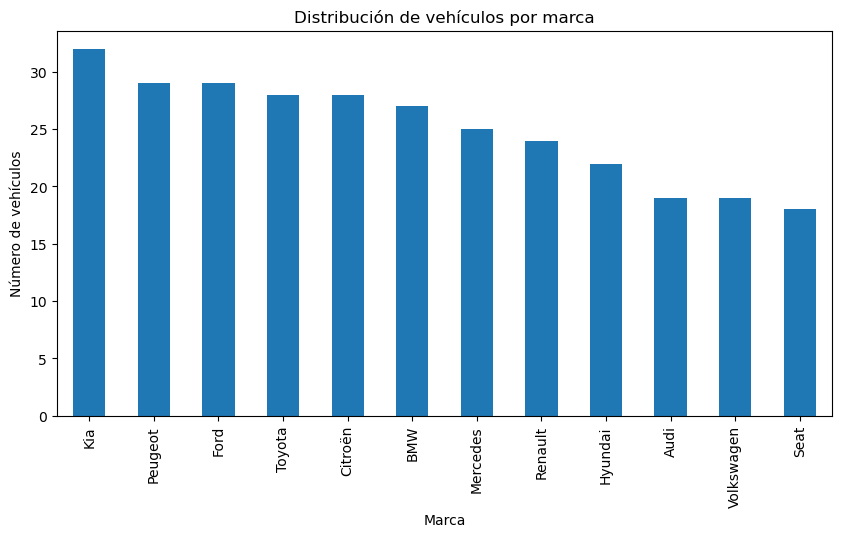

In [7]:
df_vehiculos['marca'].value_counts().plot(
    kind='bar',
    figsize=(10,5),
    title='Distribución de vehículos por marca'
)
plt.ylabel('Número de vehículos')
plt.xlabel('Marca')
plt.show()

Se observa una distribución relativamente equilibrada entre las distintas marcas, sin una dominancia extrema de una sola de ellas.
Marcas generalistas como Kia, Peugeot, Ford y Toyota presentan una mayor frecuencia.

    Distribución de modelos

In [8]:
df_vehiculos['modelo'].value_counts().head(10)

modelo
X1         14
Mondeo     11
Niro       10
Ev6        10
Clase E    10
Polo        9
408         9
Q3          8
Corolla     8
RAV4        8
Name: count, dtype: int64

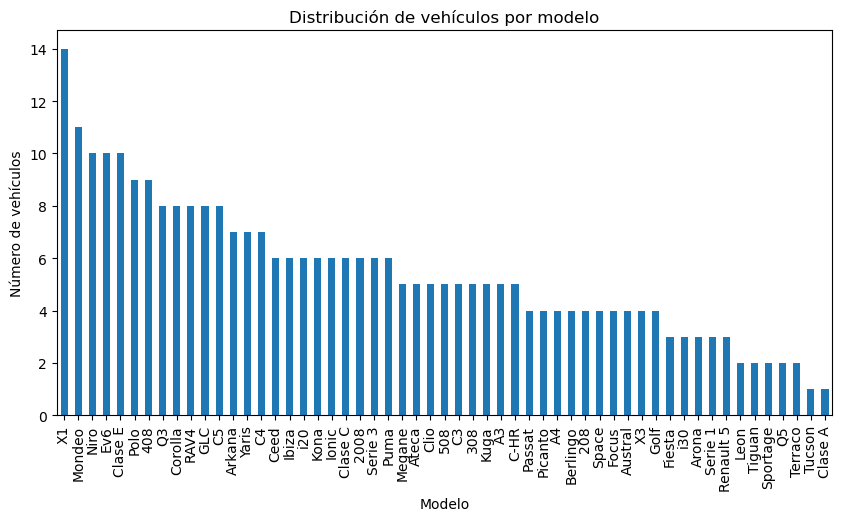

In [20]:
df_vehiculos['modelo'].value_counts().plot(
    kind='bar',
    figsize=(10,5),
    title='Distribución de vehículos por modelo'
)
plt.ylabel('Número de vehículos')
plt.xlabel('Modelo')
plt.show()

La distribución de modelos muestra que algunos vehículos concretos aparecen con mayor frecuencia, aunque no existe una concentración excesiva en un único modelo.

    Distribución por segmento de mercado

In [ ]:
df_vehiculos['segmento'].value_counts()

segmento
Compacto     102
SUV           86
Sedán         58
Executive     38
Deportivo     16
Name: count, dtype: int64

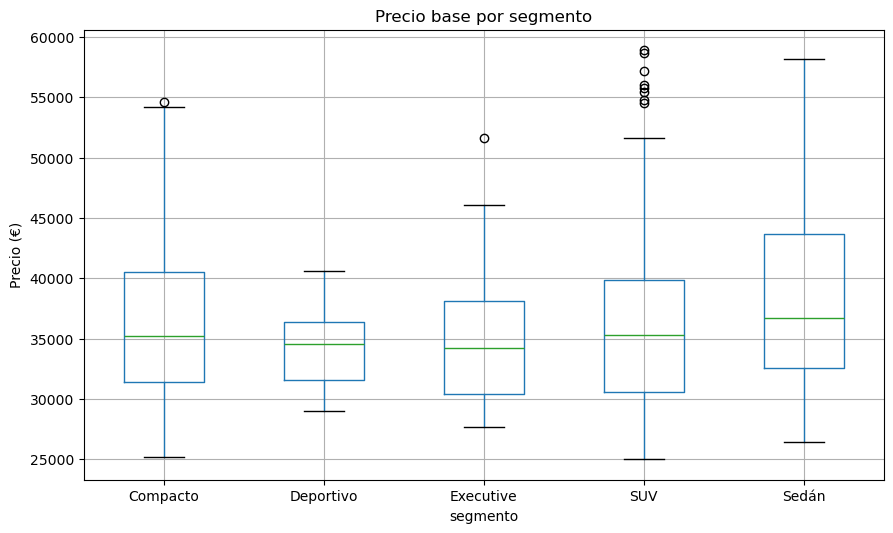

In [19]:
df_vehiculos.boxplot(
    column='precio_base',
    by='segmento',
    figsize=(10,6)
)
plt.title('Precio base por segmento')
plt.suptitle('')
plt.ylabel('Precio (€)')
plt.show()

El segmento Compacto es el más representado, seguido por los SUV, lo que refleja tendencias habituales del mercado automovilístico.
Los segmentos Executive y Deportivo presentan menor frecuencia, lo que indica que estos vehículos son menos comunes en el mercado, pero relevantes para analizar precios elevados y valores residuales.

### Relación entre características técnicas y precios

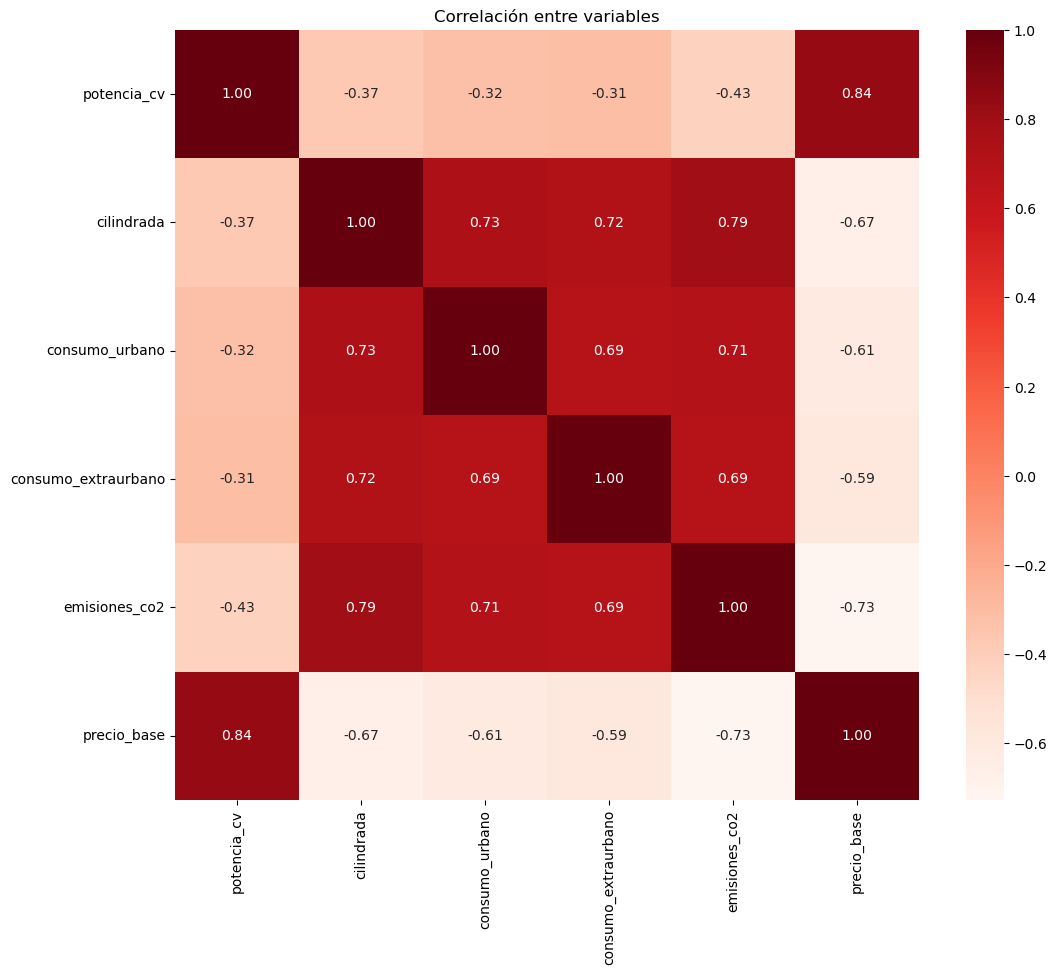

In [10]:
from pandas.plotting import scatter_matrix
import seaborn as sns
relaccion = df_vehiculos[['potencia_cv',
              'cilindrada',
              'consumo_urbano',
              'consumo_extraurbano',
              'emisiones_co2',
              'precio_base']]

cor = relaccion.corr()

plt.figure(figsize=(12,10))
sns.heatmap(cor, annot=True, fmt=".2f", cmap=plt.cm.Reds)  # mostramos solo 2 decimales
plt.title('Correlación entre variables')
plt.show()

El objetivo de esta matriz de correlación es identificar relaciones lineales entre las principales características técnicas de los vehículos y su precio base, con el fin de detectar variables potencialmente relevantes para el análisis.

    Relaccion fuerte entre: potencia_cv y precio_base (0.84)
Los vehículos con mayor potencia tienden a presentar precios base más elevados, lo que indica que las prestaciones del motor son un factor determinante en el valor del vehículo.

    Relaccion negativa entre: cilindrada y precio_base (-0.67)
Una mayor cilindrada no implica necesariamente un mayor precio base.

    Relaccion negativa entre: cilindrada y precio_base (-0.67)
Una mayor cilindrada no implica necesariamente un mayor precio base.

    Relaccion negativa entre: Precio base y consumo_urbano (-0.61)
    Relaccion negativa entre: Precio base y consumo_extraurbano (-0.59)
Los vehículos con menores consumos tienden a tener precios base más altos.

    Relaccion negativa entre: emisiones_co2 y precio_base (-0.73)
Vehículos con menores emisiones presentan precios base más elevados.

    Relaccion fuerte entre: cilindrada y consumo_urbano (0,73) / consumo_extraurbano (0,72)
    Relaccion negativa entre: potencia_cv y consumos (-0,31|-0,32) / emisiones (-0,43)
Estas relaciones indican que la potencia no depende únicamente de la cilindrada, y que existen vehículos de alta potencia con tecnologías más eficientes, como híbridos o eléctricos.

    Conclusión
El análisis de correlación muestra que el precio base del vehículo está fuertemente relacionado con la potencia y, de forma inversa, con el consumo y las emisiones de CO₂.
Estas relaciones sugieren que las prestaciones del motor y la eficiencia energética son factores clave en la valoración económica de los vehículos, justificando su inclusión en modelos predictivos en fases posteriores.

### Patrones de ventas y mantenimiento

In [11]:
df_ventas_mantenimiento[['precio_venta_real',
                          'kilometraje_venta',
                          'coste_mantenimiento_anual',
                          'incidencias_mecanicas']].describe()

,precio_venta_real,kilometraje_venta,coste_mantenimiento_anual,incidencias_mecanicas
count,600.000000,600.000000,600.000000,600.000000
mean,34625.320000,26835.851667,870.370000,0.463333
std,7230.237142,14023.227856,173.518137,0.943472
min,21773.000000,55.000000,542.000000,0.000000
25%,29492.250000,14661.000000,734.000000,0.000000
50%,33160.500000,27763.000000,852.000000,0.000000
75%,38418.000000,38716.000000,992.000000,0.000000
max,61242.000000,49936.000000,1478.000000,3.000000


Aqui se puede ver una amplia variabilidad en el precio de venta y el kilometraje, indicando la presencia de vehículos con distintos niveles de uso.

El número medio de incidencias mecánicas es bajo, lo que sugiere que la mayoría de los vehículos no presenta averías frecuentes.

In [12]:
df_ventas_mantenimiento[['kilometraje_venta', 'precio_venta_real']].corr()


,kilometraje_venta,precio_venta_real
kilometraje_venta,1.000000,-0.037815
precio_venta_real,-0.037815,1.000000


La correlación entre el kilometraje y el precio de venta real es muy débil y cercana a cero, lo que indica que, en este conjunto de datos, el kilometraje por sí solo no explica de forma significativa el precio de venta.

In [13]:
df_ventas_mantenimiento.merge(
    df_vehiculos[['vehiculo_id', 'marca']],
    on='vehiculo_id',
    how='left'
).groupby('marca')['coste_mantenimiento_anual'].mean().sort_values(ascending=False)


marca
BMW           942.413793
Audi          892.648649
Hyundai       889.583333
Ford          885.586207
Mercedes      883.574468
Peugeot       873.000000
Toyota        864.928571
Seat          853.388889
Kia           846.596491
Renault       842.901961
Volkswagen    838.540541
Citroën       824.169492
Name: coste_mantenimiento_anual, dtype: float64

Se observan diferencias claras en el coste medio de mantenimiento entre marcas.
Las marcas de gama mas alta presentan costes de mantenimiento más elevados, mientras que las marcas mas baratas tienden a mostrar costes inferiores.

In [14]:
df_ventas_mantenimiento[['incidencias_mecanicas',
                          'coste_mantenimiento_anual']].corr()

,incidencias_mecanicas,coste_mantenimiento_anual
incidencias_mecanicas,1.000000,0.035377
coste_mantenimiento_anual,0.035377,1.000000


La relación entre el número de incidencias mecánicas y el coste de mantenimiento anual es débil, lo que sugiere que los costes de mantenimiento no dependen únicamente del número de averías.

In [15]:
anio_actual = 2026

df_vehiculos['antiguedad'] = anio_actual - df_vehiculos['anio_fabricacion']

df_ventas_mantenimiento.merge(
    df_vehiculos[['vehiculo_id', 'antiguedad']],
    on='vehiculo_id',
    how='left'
)[['antiguedad', 'coste_mantenimiento_anual']].corr()

,antiguedad,coste_mantenimiento_anual
antiguedad,1.00000,0.53965
coste_mantenimiento_anual,0.53965,1.00000


Se observa una correlación positiva moderada entre la antigüedad del vehículo y el coste de mantenimiento anual, indicando que los vehículos más antiguos tienden a requerir mayores gastos de mantenimiento.

    Conclusión
El análisis exploratorio de las ventas y el mantenimiento permite identificar patrones relacionados con la antigüedad del vehículo y los costes asociados a su conservación.

Las diferencias entre marcas pueden influir en los costes de mantenimiento, factores que podrían afectar al valor del vehículo en fases posteriores.

### Hipótesis sobre factores que afectan al valor residual

- Se ha observado una correlación positiva moderada entre la antigüedad del vehículo y el coste de mantenimiento, lo que sugiere un mayor desgaste y una menor percepción de valor en vehículos más antiguos.

- Aunque la correlación directa entre kilometraje y precio de venta es débil en esta fase, el kilometraje sigue siendo un indicador del uso del vehículo y, combinado con otras variables, puede influir en el valor.

- Las diferencias observadas en el coste de mantenimiento por marca y su relación con la antigüedad indican que los costes de mantenimiento pueden afectar negativamente a la percepción de valor del vehículo

- Aunque la correlación directa es débil, las incidencias mecánicas reflejan problemas de fiabilidad que pueden influir en el precio de venta y en el valor residual a largo plazo.

- El análisis de correlación entre variables técnicas y precio base muestra que la eficiencia energética y las prestaciones influyen positivamente en la valoración económica del vehículo.

- Las puntuaciones y recomendaciones reflejan la satisfacción del cliente y pueden influir en la demanda y en el valor del vehículo.

### 1.2 Definición de Objetivos de Minería

    ¿Qué características determinan el precio de un vehículo?
Se plantea analizar qué variables técnicas (potencia, consumo, emisiones), comerciales (segmento, marca) y de percepción del cliente influyen de forma significativa en el precio del vehículo.

    ¿Podemos segmentar vehículos por perfil de uso y eficiencia?
Se propone segmentar los vehículos en función de su perfil de uso y eficiencia energética, utilizando variables como consumo, emisiones, tipo de combustible y kilometraje.

    ¿Qué factores predicen los costes de mantenimiento?
Se analizará la relación entre antigüedad, kilometraje, incidencias mecánicas, marca y costes de mantenimiento anual para identificar los factores que influyen en el gasto de mantenimiento.

    ¿Existen patrones en las ventas por temporada y región?
Se estudiarán posibles patrones temporales y geográficos en las ventas de vehículos, considerando la fecha de venta y la región del vendedor.

    ¿Cómo predecir el valor residual de un vehículo?
Se plantea la construcción de modelos predictivos que permitan estimar el valor residual del vehículo a partir de características técnicas, de uso, mantenimiento y percepción del cliente.

    ¿Influye la percepción del cliente en el precio del vehículo?
Dado que se dispone de información sobre valoraciones y recomendaciones de los clientes, resulta relevante analizar si estas opiniones del vehículo influye en su valor.

    ¿Es posible detectar vehículos con precios anormales a partir de sus características?
Posibilidad de identificar vehículos con precios anormales mediante el uso de técnicas de detección de anomalías basadas en características técnicas, de uso y de mantenimiento.

### Fase 2: Preprocesamiento y limpieza

#### - Integración de múltiples fuentes 

In [72]:
# Unificación de los dataframes
df_ventas_vehiculo = pd.merge(df_ventas_mantenimiento, df_vehiculos, on="vehiculo_id", how="left")

df_ventas_vehiculo.head()

,venta_id,vehiculo_id,fecha_venta,region_vendedor,precio_venta_real,kilometraje_venta,servicios_realizados,coste_mantenimiento_anual,incidencias_mecanicas,valor_residual_estimado,...,anio_fabricacion,combustible,transmision,potencia_cv,cilindrada,consumo_urbano,consumo_extraurbano,emisiones_co2,precio_base,segmento
0,VT001,VH001,2023-03-01,Cataluña,34536,168,0,992,0,12937,...,2018,Híbrido,Manual,147,1400,6.9,5.5,149,34600,Compacto
1,VT002,VH001,2023-01-24,País Vasco,31929,9835,1,992,0,6894,...,2018,Híbrido,Manual,147,1400,6.9,5.5,149,34600,Compacto
2,VT003,VH001,2023-10-11,País Vasco,30964,16270,3,992,0,10366,...,2018,Híbrido,Manual,147,1400,6.9,5.5,149,34600,Compacto
3,VT004,VH002,2023-10-20,Andalucía,31897,44127,0,1030,0,6739,...,2018,Gasolina,Manual,219,2000,4.1,4.1,149,36500,Sedán
4,VT005,VH003,2023-08-27,Andalucía,34964,20361,2,896,3,18098,...,2020,Híbrido,Manual,130,2200,5.7,4.3,107,34800,Deportivo


Para la construcción del dataset unificado, se ha priorizado la integridad transaccional de los datos de ventas.

- Integración Ventas-Vehículos: Se ha realizado una unión (Left Join) entre el histórico de ventas y el catálogo de vehículos. Dado que la cardinalidad es de N:1 (muchas ventas pueden referirse al mismo modelo de coche), esta operación es segura y enriquece cada venta con sus especificaciones técnicas sin alterar el número de registros (600 transacciones).
- Hemos decidido no integrar físicamente la tabla de opiniones en esta fase preliminar. El motivo es la naturaleza "uno a muchos" de las reseñas (un vehículo tiene múltiples opiniones). Una unión directa duplicaría los registros de ventas, introduciendo sesgo en los futuros modelos de predicción de precios. Y si se tratara de unir haciendo medias y modas se perdería el texto de las reseñas.

Trabajaremos con un dataset de ventas y vehiculos para los modelos numéricos y agruparemos con las opiniones en los apartados que requieran de ellas y en las que se requiera.

In [73]:
df_ventas_vehiculo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   venta_id                   600 non-null    object 
 1   vehiculo_id                600 non-null    object 
 2   fecha_venta                600 non-null    object 
 3   region_vendedor            600 non-null    object 
 4   precio_venta_real          600 non-null    int64  
 5   kilometraje_venta          600 non-null    int64  
 6   servicios_realizados       600 non-null    int64  
 7   coste_mantenimiento_anual  600 non-null    int64  
 8   incidencias_mecanicas      600 non-null    int64  
 9   valor_residual_estimado    600 non-null    int64  
 10  marca                      600 non-null    object 
 11  modelo                     600 non-null    object 
 12  anio_fabricacion           600 non-null    int64  
 13  combustible                600 non-null    object 

In [74]:
#Valores realistas
df_ventas_vehiculo.describe()

,precio_venta_real,kilometraje_venta,servicios_realizados,coste_mantenimiento_anual,incidencias_mecanicas,valor_residual_estimado,anio_fabricacion,potencia_cv,cilindrada,consumo_urbano,consumo_extraurbano,emisiones_co2,precio_base
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,34625.320000,26835.851667,3.016667,870.370000,0.463333,21677.175000,2021.211667,179.285000,1475.333333,5.390167,4.530500,105.101667,36547.666667
std,7230.237142,14023.227856,2.038786,173.518137,0.943472,10559.684987,1.954456,53.542461,707.266049,1.773451,1.233189,49.728022,7307.009091
min,21773.000000,55.000000,0.000000,542.000000,0.000000,5340.000000,2018.000000,90.000000,0.000000,1.500000,1.800000,0.000000,25000.000000
25%,29492.250000,14661.000000,1.000000,734.000000,0.000000,13263.750000,2019.000000,134.000000,1200.000000,4.500000,3.900000,92.000000,31150.000000
50%,33160.500000,27763.000000,3.000000,852.000000,0.000000,19264.500000,2021.000000,174.000000,1600.000000,5.600000,4.600000,120.000000,35150.000000
75%,38418.000000,38716.000000,5.000000,992.000000,0.000000,28073.250000,2023.000000,217.000000,2000.000000,6.800000,5.500000,140.000000,39700.000000
max,61242.000000,49936.000000,6.000000,1478.000000,3.000000,58200.000000,2024.000000,336.000000,2200.000000,8.000000,6.500000,160.000000,58900.000000


In [75]:
df_opiniones.describe()

,puntuacion_conjunta,confort,seguridad,eficiencia,diseno,fiabilidad
count,500.00000,500.000000,500.000000,500.00000,500.00000,500.000000
mean,3.75940,3.731000,3.935800,3.75120,3.63300,3.619600
std,0.79785,0.900289,0.850685,0.92802,0.99228,0.918359
min,1.00000,1.000000,1.000000,1.00000,1.00000,1.000000
25%,3.20000,3.200000,3.375000,3.10000,3.00000,2.900000
50%,3.80000,3.800000,4.000000,3.80000,3.70000,3.700000
75%,4.40000,4.400000,4.600000,4.50000,4.40000,4.400000
max,5.00000,5.000000,5.000000,5.00000,5.00000,5.000000


In [76]:
#Comprobación de valores nulos
df_ventas_vehiculo.isnull().sum()

venta_id                     0
vehiculo_id                  0
fecha_venta                  0
region_vendedor              0
precio_venta_real            0
kilometraje_venta            0
servicios_realizados         0
coste_mantenimiento_anual    0
incidencias_mecanicas        0
valor_residual_estimado      0
marca                        0
modelo                       0
anio_fabricacion             0
combustible                  0
transmision                  0
potencia_cv                  0
cilindrada                   0
consumo_urbano               0
consumo_extraurbano          0
emisiones_co2                0
precio_base                  0
segmento                     0
dtype: int64

In [77]:
df_opiniones.isnull().sum()

review_id              0
vehiculo_id            0
cliente_id             0
puntuacion_conjunta    0
confort                0
seguridad              0
eficiencia             0
diseno                 0
fiabilidad             0
recomendacion          0
texto_review           0
dtype: int64

- No se pueden observar valores atípicos y nulos en los dos datasets con los que trabajaremos

#### - Limpieza y tratamiento de valores anomalos

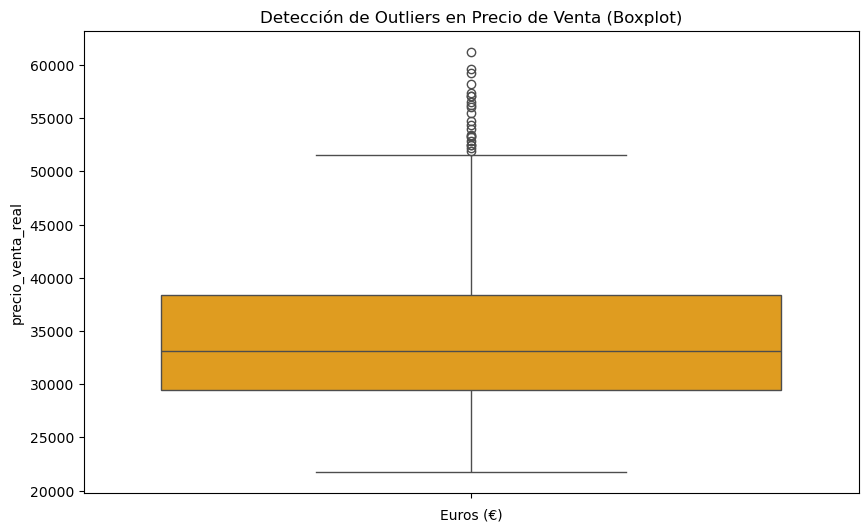

In [89]:
#Analisis de outlier en precio de venta
plt.figure(figsize=(10,6))
sns.boxplot(df_ventas_vehiculo['precio_venta_real'], color='orange')
plt.title('Detección de Outliers en Precio de Venta (Boxplot)')
plt.xlabel('Euros (€)')
plt.show()

Podemos observar que hay precios que superar el valor máximo no atípico. Pero ¿que tipo de vehículos son estos?

In [79]:
# Cálculo numérico del IQR
Q1 = df_ventas_vehiculo['precio_venta_real'].quantile(0.25)
Q3 = df_ventas_vehiculo['precio_venta_real'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR


#Los outliers son:
outliers = df_ventas_vehiculo[df_ventas_vehiculo['precio_venta_real'] > limite_superior]
print("Número de outliers detectados:", outliers.shape[0])
#Mostar marcas y modelos de los outliers
print(outliers[['marca', 'modelo', 'precio_venta_real','segmento']])

Número de outliers detectados: 22
        marca     modelo  precio_venta_real  segmento
28    Renault    Austral              56050       SUV
39        BMW         X1              59659       SUV
40        BMW         X1              61242       SUV
45   Mercedes    Clase E              52516     Sedán
58       Ford       Kuga              54014       SUV
59       Ford       Kuga              53224       SUV
60       Ford       Kuga              58232       SUV
116       Kia       Niro              52883       SUV
117       Kia       Niro              56512       SUV
170   Hyundai      Ionic              53428       SUV
197   Renault  Renault 5              54735     Sedán
206       BMW         X3              56198     Sedán
208    Toyota      Yaris              52191  Compacto
213       Kia       Ceed              55497     Sedán
304       BMW    Serie 3              51911       SUV
358      Ford     Mondeo              52505       SUV
363   Hyundai        i30              54373  Com

Podemos comprobar que se corresponden a vehículos de gama alta, por lo que estos valores no son errores, sino precios legítimos. Eliminarlos sesgaría el modelo, impidiéndole predecir correctamente vehículos de gama alta.

In [ ]:
#Validación de cilindrada
cilindrada_cero = df_ventas_vehiculo[df_ventas_vehiculo['cilindrada'] == 0]
print("Número de vehículos con cilindrada cero:", cilindrada_cero.shape[0])


Número de vehículos con cilindrada cero: 93


Hemos podido comprobar que hay vehículos con cilindrada cero, de modo que tenemos que comprobar que todos los vehículos con esta cilindrada sean electricos (puesto que son los únicos que no tienen cilindros) en caso de que haya otro tipo se trataría de un error.

In [81]:
print(cilindrada_cero['combustible'].unique()) # Debería salir solo 'Eléctrico'

['Eléctrico']


Tan solo son coches eléctricos por lo que no hay valores incorrectos

In [83]:
#Validación del consumo medio
consumo_cero_urbano = df_ventas_vehiculo[(df_ventas_vehiculo['consumo_urbano'] <= 0) | (df_ventas_vehiculo['consumo_urbano'] > 20)]
print("Número de vehículos con consumo urbano no realista:", consumo_cero_urbano.shape[0])

consumo_cero_carr = df_ventas_vehiculo[(df_ventas_vehiculo['consumo_extraurbano'] <= 0) | (df_ventas_vehiculo['consumo_extraurbano'] > 20)]
print("Número de vehículos con consumo extraurbano no realista:", consumo_cero_carr.shape[0])

Número de vehículos con consumo urbano no realista: 0
Número de vehículos con consumo extraurbano no realista: 0


No hemos encontrado valores negativos ni consumos imposibles (0 L/100km en coches de combustión o > 20 L/100km) sino que no pasan los consumos más altos de 9 L/100km.

In [85]:
#Comprobación de valores missing en puntuaciones

#Unir dataframes de ventas y opiniones
df_completo = pd.merge(df_ventas_vehiculo, df_opiniones, on="vehiculo_id", how="left")

#Columnas que queremos comprobar
cols_puntuacion = ['puntuacion_conjunta', 'confort', 'seguridad', 
                   'eficiencia', 'diseno', 'fiabilidad']

#Comprobar valores missing
n_ventas_total = len(df_completo)
n_sin_review = df_completo['puntuacion_conjunta'].isnull().sum()
porcentaje_missing = (n_sin_review / n_ventas_total) * 100

print(f"Total de ventas registradas: {n_ventas_total}")
print(f"Ventas sin ninguna opinión de cliente: {n_sin_review}")
print(f"Porcentaje de datos faltantes en puntuaciones: {porcentaje_missing:.2f}%")

#Ver  coche vendidio sin review
print("\nEjemplo de vehículos vendidos sin feedback (Valores Missing):")
missing_reviews = df_completo[df_completo['puntuacion_conjunta'].isnull()]
print(missing_reviews[['vehiculo_id', 'marca', 'modelo', 'puntuacion_conjunta','confort','seguridad','eficiencia','diseno','fiabilidad']].head())

Total de ventas registradas: 1123
Ventas sin ninguna opinión de cliente: 111
Porcentaje de datos faltantes en puntuaciones: 9.88%

Ejemplo de vehículos vendidos sin feedback (Valores Missing):
   vehiculo_id marca modelo  puntuacion_conjunta  confort  seguridad  \
5        VH003   Kia    Ev6                  NaN      NaN        NaN   
6        VH004  Ford   Puma                  NaN      NaN        NaN   
17       VH008  Ford   Puma                  NaN      NaN        NaN   
18       VH008  Ford   Puma                  NaN      NaN        NaN   
19       VH009  Ford   Kuga                  NaN      NaN        NaN   

    eficiencia  diseno  fiabilidad  
5          NaN     NaN         NaN  
6          NaN     NaN         NaN  
17         NaN     NaN         NaN  
18         NaN     NaN         NaN  
19         NaN     NaN         NaN  


Al analizar el fichero origen de opiniones (Opiniones-clientes.xml), no se encontraron valores nulos; sin embargo, al cruzar los datos con las ventas, existen vehículos que no poseen reseñas.

Dado que las opiniones se integrarán dinámicamente en fases posteriores, no se imputarán valores artificiales (como la media) en esta fase para no introducir "ruido".

In [87]:
#Normalización de variables técnicas
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
variables_tecnicas = ['cilindrada', 'potencia_cv']
for var in variables_tecnicas:
    df_ventas_vehiculo[[var]] = scaler.fit_transform(df_ventas_vehiculo[[var]])

df_ventas_vehiculo.head()

,venta_id,vehiculo_id,fecha_venta,region_vendedor,precio_venta_real,kilometraje_venta,servicios_realizados,coste_mantenimiento_anual,incidencias_mecanicas,valor_residual_estimado,...,anio_fabricacion,combustible,transmision,potencia_cv,cilindrada,consumo_urbano,consumo_extraurbano,emisiones_co2,precio_base,segmento
0,VT001,VH001,2023-03-01,Cataluña,34536,168,0,992,0,12937,...,2018,Híbrido,Manual,0.231707,0.636364,6.9,5.5,149,34600,Compacto
1,VT002,VH001,2023-01-24,País Vasco,31929,9835,1,992,0,6894,...,2018,Híbrido,Manual,0.231707,0.636364,6.9,5.5,149,34600,Compacto
2,VT003,VH001,2023-10-11,País Vasco,30964,16270,3,992,0,10366,...,2018,Híbrido,Manual,0.231707,0.636364,6.9,5.5,149,34600,Compacto
3,VT004,VH002,2023-10-20,Andalucía,31897,44127,0,1030,0,6739,...,2018,Gasolina,Manual,0.524390,0.909091,4.1,4.1,149,36500,Sedán
4,VT005,VH003,2023-08-27,Andalucía,34964,20361,2,896,3,18098,...,2020,Híbrido,Manual,0.162602,1.000000,5.7,4.3,107,34800,Deportivo


Para evitar que variables con escalas grandes (como cilindrada: 1200-2200) dominen sobre variables pequeñas (como consumo: 4-8) en algoritmos basados en distancia (como K-Nearest Neighbors o SVM), se ha aplicado una normalización Min-Max. Si no normalizo, la cilindrada (2000) pesaría mucho más que la potencia (150) simplemente por ser un número más grande, falseando el resultado.

### Fase 3: Minería de Datos (KDD)